<a href="https://colab.research.google.com/github/betiman88/Dani/blob/main/Python_Vgsales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd #Importar libreria
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("vgsales.csv")  # Carga de datos y asignar variable

In [4]:
df["Rank"].diff().value_counts()

,count
Rank,
1.0,16595
2.0,2


In [ ]:
df[df["Rank"].diff() != 1][["Rank", "Name"]]

,Rank,Name
0,1,Wii Sports
653,655,Monopoly
14198,14201,Monster Guardians


In [ ]:
df.loc[648:656, ["Rank", "Name", "Global_Sales"]]

,Rank,Name,Global_Sales
648,649,Theme Hospital,2.40
649,650,Frogger's Adventures: Temple of the Frog,2.39
650,651,Need for Speed (2015),2.39
651,652,Zumba Fitness,2.39
652,653,LEGO Indiana Jones: The Original Adventures,2.39
653,655,Monopoly,2.39
654,656,Batman: Arkham Origins,2.39
655,657,Dead Island,2.39
656,658,Guitar Hero,2.38


In [ ]:
df[df["Rank"].diff() > 1][["Rank", "Name", "Global_Sales"]]

,Rank,Name,Global_Sales
653,655,Monopoly,2.39
14198,14201,Monster Guardians,0.03


In [ ]:
df["Rank"] = range(1, len(df) + 1) # el dataset tenia un error ya que habia un salto en el ranking, con esta linea queda subsanado

In [ ]:
df.loc[648:656, ["Rank", "Name"]]

,Rank,Name
648,649,Theme Hospital
649,650,Frogger's Adventures: Temple of the Frog
650,651,Need for Speed (2015)
651,652,Zumba Fitness
652,653,LEGO Indiana Jones: The Original Adventures
653,654,Monopoly
654,655,Batman: Arkham Origins
655,656,Dead Island
656,657,Guitar Hero


In [ ]:
df["Rank"].is_unique

True

In [ ]:
# Dimensiones del dataset
df.shape

(16598, 11)

In [ ]:
# Información general: columnas, tipos de datos y valores nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:

# Resumen estadístico de las variables numéricas
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16598.000000,16327.000000,16598.000000,16598.000000,16598.000000,16598.000000,16598.000000
mean,8299.500000,2006.406443,0.264667,0.146652,0.077782,0.048063,0.537441
std,4791.574219,5.828981,0.816683,0.505351,0.309291,0.188588,1.555028
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4150.250000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8299.500000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12448.750000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.470000
max,16598.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16598 entries, 0 to 16597
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Rank          16598 non-null  int64  
 1   Name          16598 non-null  object 
 2   Platform      16598 non-null  object 
 3   Year          16327 non-null  float64
 4   Genre         16598 non-null  object 
 5   Publisher     16540 non-null  object 
 6   NA_Sales      16598 non-null  float64
 7   EU_Sales      16598 non-null  float64
 8   JP_Sales      16598 non-null  float64
 9   Other_Sales   16598 non-null  float64
 10  Global_Sales  16598 non-null  float64
dtypes: float64(6), int64(1), object(4)
memory usage: 1.4+ MB


In [ ]:
df.duplicated().sum() #Buscamos si hay duplicados , en este caso no los hay

np.int64(0)

In [ ]:
df.isnull().sum() #Comprobamos las columnas que contienen valores nulos y nos diga el total

,0
Rank,0
Name,0
Platform,0
Year,271
Genre,0
Publisher,0
NA_Sales,0
EU_Sales,0
JP_Sales,0
Other_Sales,0


In [ ]:
df[df["Year"].isnull()] #PEdimos las filas que tengan valor nulo en year

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
179,180,Madden NFL 2004,PS2,NaN,Sports,Electronic Arts,4.26,0.26,0.01,0.71,5.23
377,378,FIFA Soccer 2004,PS2,NaN,Sports,Electronic Arts,0.59,2.36,0.04,0.51,3.49
431,432,LEGO Batman: The Videogame,Wii,NaN,Action,Warner Bros. Interactive Entertainment,1.86,1.02,0.00,0.29,3.17
470,471,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,Unknown,1.57,1.02,0.00,0.41,3.00
607,608,Space Invaders,2600,NaN,Shooter,Atari,2.36,0.14,0.00,0.03,2.53
...,...,...,...,...,...,...,...,...,...,...,...
16307,16310,Freaky Flyers,GC,NaN,Racing,Unknown,0.01,0.00,0.00,0.00,0.01
16327,16330,Inversion,PC,NaN,Shooter,Namco Bandai Games,0.01,0.00,0.00,0.00,0.01
16366,16369,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,Unknown,0.01,0.00,0.00,0.00,0.01
16427,16430,Virtua Quest,GC,NaN,Role-Playing,Unknown,0.01,0.00,0.00,0.00,0.01


In [ ]:
df[df["Publisher"].isnull()] #Pedimos las filas que tienen valor nulo en Publisher

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales


In [ ]:
df["Publisher"] = df["Publisher"].fillna("Unknown") #Pedimos que en cada fila en publisher que contenga un nulo , cambie a "UNKNOWN"

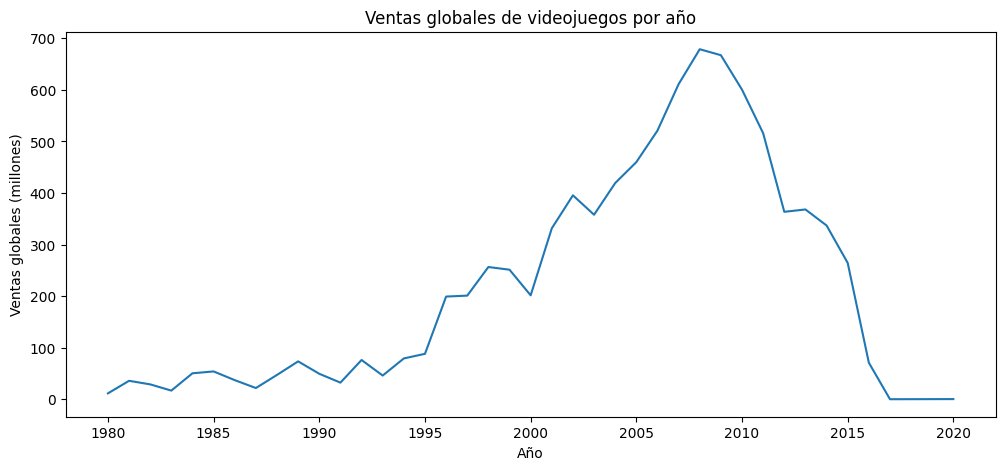

In [ ]:
ventas_año = df.groupby("Year")["Global_Sales"].sum() #Mostramos una grafica para comprobar que este todo correcto y no tire erorres

plt.figure(figsize=(12, 5))
ventas_año.plot()
plt.title("Ventas globales de videojuegos por año")
plt.xlabel("Año")
plt.ylabel("Ventas globales (millones)")
plt.show()

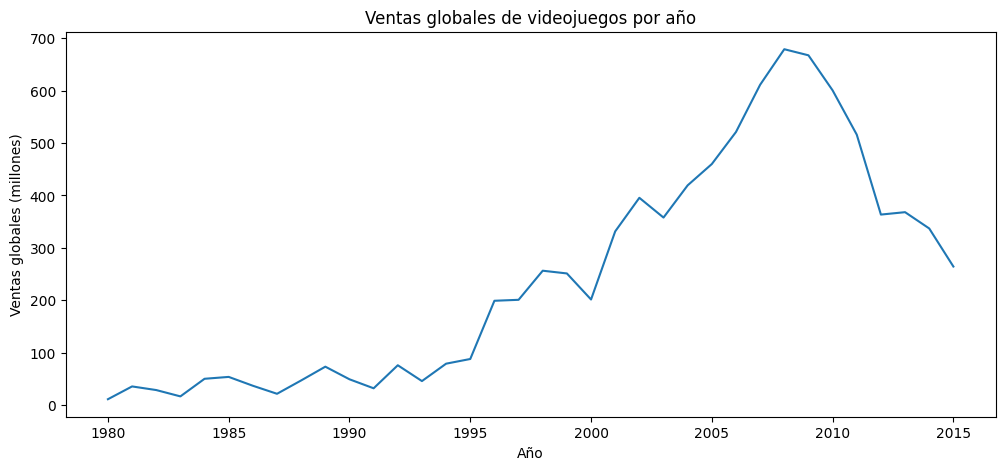

In [10]:
ventas_año = df.groupby("Year")["Global_Sales"].sum() ### Vamos a limitar los años del estudio en el grafico a 2015 ya que en adelante hay valores nulos

ventas_año = ventas_año[(ventas_año.index >= 1980) & (ventas_año.index <= 2015)]

plt.figure(figsize=(12, 5))
ventas_año.plot()

plt.title("Ventas globales de videojuegos por año")
plt.xlabel("Año")
plt.ylabel("Ventas globales (millones)")

plt.show()

In [ ]:
df.to_csv("vgsales_limpio.csv", index=False) #Exportacion del dataset limpio